# CodeLab 5. Многослойная нейронная сеть

В этом задании вам предстоит:
- реализовать слои ReLU и FullyConnected;
- составить из них нейронную сеть;
- переобучить сеть на небольшом наборе данных
- обучить модель на полной выборке и получить точность > 40%


In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

## Загрузка датасета CIFAR-10 и нормализация данных

In [2]:
# Очистим значения переменных, чтобы избежать проблем с излишним потреблением памяти
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Проверим размер входных и выходных векторов.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)


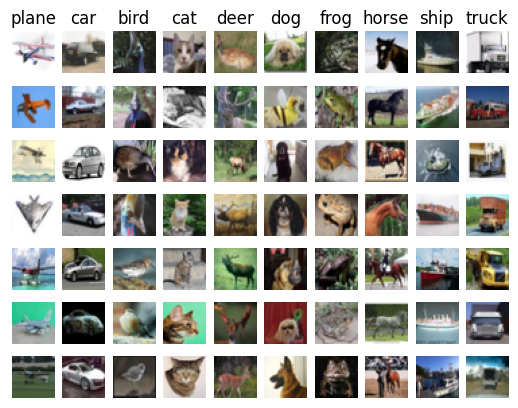

In [3]:
# Перед началом работы полезно посмотреть на данные.
# Отобразим пример из каждого класса.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [4]:
# Для удобства преобразуем двумерные изображения в одномерные вектора fp64
X_train = np.reshape(X_train, (X_train.shape[0], -1)).astype(np.float64)
X_test = np.reshape(X_test, (X_test.shape[0], -1)).astype(np.float64)
y_train = y_train.flatten()
y_test = y_test.flatten()
# Проверим размер полученных данных
print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)
print('Training label shape: ', y_train.shape)
print('Test label shape: ', y_test.shape)

Training data shape:  (50000, 3072)
Test data shape:  (10000, 3072)
Training label shape:  (50000,)
Test label shape:  (10000,)


In [5]:
# Разделим данные на выборки train, val, test

num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 16

# Для валидации используем подвыборку train
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# На остальных данных из train будем тренировать модель
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# Чтобы ускорить разработку, создадим также небольшую dev выборку 
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# Для тестирования используем оригинальную выборку test
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 3072)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


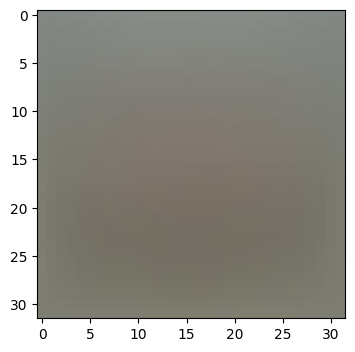

(49000, 3072) (1000, 3072) (1000, 3072) (16, 3072)


In [6]:
# Нормализуем значения яркости пикселей 
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 

# визуализируем среднюю яркость
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()

# Вычтем средние значения яркости
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image


print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Функции для сравнения аналитического градиента с градиентом, вычисленного методом конечных разностей. 

In [14]:
def check_gradient(f, x, delta=1e-5, tol=1e-4):
    """
    Checks the implementation of analytical gradient by comparing
    it to numerical gradient using two-point formula
    Arguments:
      f: function that receives x and computes value and gradient
      x: np array, initial point where gradient is checked
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient
    Return:
      bool indicating whether gradients match or not
    """
    assert isinstance(x, np.ndarray)
    assert x.dtype == float
    
    orig_x = x.copy()
    fx, analytic_grad = f(x)
    assert np.all(np.isclose(orig_x, x, tol)), "Functions shouldn't modify input variables"

    assert analytic_grad.shape == x.shape
    analytic_grad = analytic_grad.copy()
    
    # We will go through every dimension of x and compute numeric
    # derivative for it
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix = it.multi_index
        analytic_grad_at_ix = analytic_grad[ix] 
        x0 = x.copy()
        x1 = x.copy()
        x0[ix] += delta
        x1[ix] -= delta
        
        numeric_grad_at_ix = (f(x0)[0] - f(x1)[0]) / (2 * delta)
        print(analytic_grad_at_ix , numeric_grad_at_ix)

         #TODO compute value of numeric gradient of f to idx
        if not np.isclose(numeric_grad_at_ix, analytic_grad_at_ix, tol):
            print("Gradients are different at %s. Analytic: %2.5f, Numeric: %2.5f" % (ix, analytic_grad_at_ix, numeric_grad_at_ix))
            return False

        it.iternext()
    
    print("Gradient check passed!")
    return True


In [9]:
def check_layer_gradient(layer, x, delta=1e-5, tol=1e-4):
    """
    Checks gradient correctness for the input and output of a layer
    Arguments:
      layer: neural network layer, with forward and backward functions
      x: starting point for layer input
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient
    Returns:
      bool indicating whether gradients match or not
    """
    output = layer.forward(x)
    output_weight = np.random.randn(*output.shape)

    def helper_func(x):
        output = layer.forward(x)
        loss = np.sum(output * output_weight)
        d_out = np.ones_like(output) * output_weight
        grad = layer.backward(d_out)
        return loss, grad

    return check_gradient(helper_func, x, delta, tol)

In [10]:
def check_layer_param_gradient(layer, x,
                               param_name,
                               delta=1e-5, tol=1e-4):
    """
    Checks gradient correctness for the parameter of the layer
    Arguments:
      layer: neural network layer, with forward and backward functions
      x: starting point for layer input
      param_name: name of the parameter
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient
    Returns:
      bool indicating whether gradients match or not
    """
    param = layer.params()[param_name]
    initial_w = param.value

    output = layer.forward(x)
    output_weight = np.random.randn(*output.shape)

    def helper_func(w):
        param.value = w
        output = layer.forward(x)
        loss = np.sum(output * output_weight)
        d_out = np.ones_like(output) * output_weight
        layer.backward(d_out)
        grad = param.grad
        return loss, grad

    return check_gradient(helper_func, initial_w, delta, tol)

In [11]:
def check_model_gradient(model, X, y,
                         delta=1e-5, tol=1e-4):
    """
    Checks gradient correctness for all model parameters
    Arguments:
      model: neural network model with compute_loss_and_gradients
      X: batch of input data
      y: batch of labels
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient
    Returns:
      bool indicating whether gradients match or not
    """
    params = model.params()

    for param_key in params:
        print("Checking gradient for %s" % param_key)
        param = params[param_key]
        initial_w = param.value

        def helper_func(w):
            param.value = w
            loss = model.compute_loss_and_gradients(X, y)
            grad = param.grad
            return loss, grad

        if not check_gradient(helper_func, initial_w, delta, tol):
            return False

    return True

## Задание 1. ReLU Layer

Мы будем реализовывать необходимые нам слои по очереди. Каждый слой должен реализовать:
- прямой проход (forward pass), который генерирует выход слоя по входу и запоминает необходимые данные
- обратный проход (backward pass), который получает градиент по выходу слоя и вычисляет градиент по входу и по параметрам

Начнем с ReLU, у которого обучаемых параметров нет.

In [12]:
class ReLULayer:
    def __init__(self):
        self.mask = None

    def forward(self, X):
        # TODO: Implement forward pass
        # Hint: you'll need to save some information about X
        # to use it later in the backward pass
        #raise Exception("Not implemented!")
        self.mask = X > 0
        return np.maximum(0, X)


    def backward(self, d_out):
        """
        Backward pass
        Arguments:
        d_out, np array (batch_size, num_features) - gradient
           of loss function with respect to output
        Returns:
        d_result: np array (batch_size, num_features) - gradient
          with respect to input
        """
        # TODO: Implement backward pass
        # Your final implementation shouldn't have any loops
        return d_out * self.mask
        

    def params(self):
        # ReLU Doesn't have any parameters
        return {}

In [15]:
# TODO: Implement ReLULayer 
# Note: you'll need to copy implementation of the gradient_check function from the previous assignment

X = np.array([[1,-2,3],
              [-1, 2, 0.1]
              ])

assert check_layer_gradient(ReLULayer(), X)

0.2862044233765239 0.286204423360914
0.0 0.0
-1.0178036865222404 -1.0178036865315931
0.0 0.0
-1.1354531677533315 -1.1354531677554291
-0.8797404608499327 -0.8797404608795744
Gradient check passed!


## Задание 2. FullyConnected (Dense) Layer

А теперь реализуем полносвязный слой (fully connected layer), у которого будет два массива параметров: W (weights) и B (bias).

Все параметры наши слои будут использовать для параметров специальный класс `Param`, в котором будут храниться значения параметров и градиенты этих параметров, вычисляемые во время обратного прохода.

Это даст возможность аккумулировать (суммировать) градиенты из разных частей функции потерь, например, из cross-entropy loss и regularization loss.

In [16]:
class Param:
    """
    Trainable parameter of the model
    Captures both parameter value and the gradient
    """

    def __init__(self, value):
        self.value = value
        self.grad = np.zeros_like(value)

In [17]:
class FullyConnectedLayer:
    def __init__(self, n_input, n_output):
        self.W = Param(0.001 * np.random.randn(n_input, n_output))
        self.B = Param(0.001 * np.random.randn(1, n_output))
        self.X = None

    def forward(self, X):
        # TODO: Implement forward pass
        # Your final implementation shouldn't have any loops
        # raise Exception("Not implemented!")
        self.X = X
        return X @ self.W.value + self.B.value


    def backward(self, d_out):
        """
        Backward pass
        Computes gradient with respect to input and
        accumulates gradients within self.W and self.B
        Arguments:
        d_out, np array (batch_size, n_output) - gradient
           of loss function with respect to output
        Returns:
        d_result: np array (batch_size, n_input) - gradient
          with respect to input
        """
        # TODO: Implement backward pass
        # Compute both gradient with respect to input
        # and gradients with respect to W and B
        # Add gradients of W and B to their `grad` attribute

        # It should be pretty similar to linear classifier from
        # the previous assignment
        # raise Exception("Not implemented!")
        # print('d_out shape is ', d_out.shape)
        # print('self.W shape is ', self.W.value.shape) 
        d_input = d_out @ self.W.value.T
        self.W.grad += self.X.T @ d_out
        self.B.grad += np.sum(d_out, axis=0, keepdims=True)

        return d_input

    def params(self):
        return {'W': self.W, 'B': self.B}

In [18]:
# TODO: Implement FullyConnected layer forward and backward methods
assert check_layer_gradient(FullyConnectedLayer(3, 4), X)
# TODO: Implement storing gradients for W and B
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'W')
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'B')

0.0014541201073093343 0.001454120107397677
-0.0004929970625906664 -0.0004929970626177393
-0.0010873637426593134 -0.0010873637427098737
0.0008083702902917377 0.0008083702902591041
-0.0015197137161415551 -0.0015197137161323743
0.002224989920475853 0.0022249899204540916
Gradient check passed!
0.8337698114371246 0.8337698114371187
-1.325231115364886 -1.3252311153648908
0.6849232493358407 0.684923249335851
-3.344819005687569 -3.3448190056875773
-1.6675396228742492 -1.6675396228742807
2.650462230729772 2.6504622307297816
-1.3698464986716814 -1.369846498671702
6.689638011375138 6.689638011375112
2.3361009401117045 2.336100940111699
-0.17562742024446718 -0.17562742024444972
1.3817151024928578 1.3817151024928842
-3.761341418917406 -3.7613414189173984
Gradient check passed!
0.20681274380195835 0.20681274380202408
-0.7311963957467772 -0.731196395746883
1.7991887292911117 1.7991887292911206
0.2799159244974706 0.2799159244974356
Gradient check passed!


## Задание 3. Создаем двухслойную нейронную сеть

Теперь мы реализуем простейшую нейронную сеть с двумя полносвязным слоями и нелинейностью ReLU. Реализуйте функцию `compute_loss_and_gradients`, она должна запустить прямой и обратный проход через оба слоя для вычисления градиентов.

Не забудьте реализовать очистку градиентов в начале функции.

In [19]:
# Copied from previous
def softmax_with_cross_entropy(X, y):
    """
    Computes softmax and cross-entropy loss for model predictions,
    including the gradient
    Arguments:
      predictions, np array, shape is either (N) or (batch_size, N) -
        classifier output
      target_index: np array of int, shape is (1) or (batch_size) -
        index of the true class for given sample(s)
    Returns:
      loss, single value - cross-entropy loss
      dprediction, np array same shape as predictions - gradient of predictions by loss value
    """
    N = X.shape[0]
    X -= np.max(X)
    Exps = np.exp(X)
    # S.shape = N, C
    S = Exps / Exps.sum(axis=1, keepdims=True)
    # loss.shape = 1
    loss = - np.log(S[range(N), y]).mean()
    S[range(N), y] -= 1
    d_out = S / N
    return loss, d_out

def l2_regularization(W, reg_strength):
    loss = 0.5 * reg_strength * np.sum(W*W)
    grad = np.dot(W,reg_strength)
    return loss, grad

In [20]:
class TwoLayerNet:
    """ Neural network with two fully connected layers """

    def __init__(self, n_input, n_output, hidden_layer_size, reg):
        """
        Initializes the neural network
        Arguments:
        n_input, int - dimension of the model input
        n_output, int - number of classes to predict
        hidden_layer_size, int - number of neurons in the hidden layer
        reg, float - L2 regularization strength
        """
        self.reg = reg
        # TODO Create list with necessary layers
        self.layers = [
        FullyConnectedLayer(n_input, hidden_layer_size),
        ReLULayer(),
        FullyConnectedLayer(hidden_layer_size, n_output)
    ]
        


    def compute_loss_and_gradients(self, X, y):
        """
        Computes total loss and updates parameter gradients
        on a batch of training examples
        Arguments:
        X, np array (batch_size, input_features) - input data
        y, np array of int (batch_size) - classes
        """
        
        # Before running forward and backward pass through the model,
        # clear parameter gradients aggregated from the previous pass
        
        # TODO Set parameter gradient to zeros
        # Hint: using self.params() might be useful!
        for param in self.params().values():
            param.grad = np.zeros_like(param.value)


        # TODO Compute loss and fill param gradients
        # by running forward and backward passes through the model
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        loss, d_out = softmax_with_cross_entropy(out, y) 
        for layer in reversed(self.layers):
            d_out = layer.backward(d_out)   

        # TODO After that, implement l2 regularization on all params
        # Hint: self.params() is useful again!
        # raise Exception("Not implemented!")
        for param in self.params().values():
            loss += self.reg * np.sum(param.value ** 2)
            param.grad += 2 * self.reg * param.value

        return loss

    def predict(self, X):
        """
        Produces classifier predictions on the set
        Arguments:
          X, np array (test_samples, num_features)
        Returns:
          y_pred, np.array of int (test_samples)
        """
        # TODO: Implement predict
        # Hint: some of the code of the compute_loss_and_gradients
        # can be reused
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return np.argmax(out, axis=1)

    def params(self):
        result = {}
        name = 0
        # TODO Implement aggregating all of the params
        for i, layer in enumerate(self.layers):
            for name, param in layer.params().items():
                result[f"{name}_{i}"] = param

        return result

In [21]:
# TODO: implement compute_loss_and_gradients function
model = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 3, reg = 0)
loss = model.compute_loss_and_gradients(X_train[:2], y_train[:2])

# TODO Now implement backward pass and aggregate all of the params
check_model_gradient(model, X_train[:2], y_train[:2])

Checking gradient for W_0
-0.007550745135194075 -0.007550745140250114
-0.03973430952559293 -0.039734309531525014
0.030236093049638233 0.030236093029323282
-0.013259573345175772 -0.01325957335041039
-0.04103203892283263 -0.04103203892213969
0.03703592630072075 0.03703592630355246
-0.017626112982532437 -0.017626112991386833
-0.038531896208789294 -0.03853189620706132
0.040285391861374135 0.040285391866845544
0.0013110444830766962 0.0013110444729846904
-0.048283169277098435 -0.04828316928495723
0.025582953766682678 0.025582953777636416
-0.0005340126842440061 -0.0005340126563169179
-0.049554559698067525 -0.04955455970012678
0.028256653102664418 0.028256653084035573
-0.0013725562843749848 -0.0013725562686417445
-0.04811585395813324 -0.0481158539678006
0.02834507153724284 0.028345071512170247
0.00839201335715433 0.008392013373104135
-0.04490265731709423 -0.04490265732570719
0.016159286847777957 0.016159286841954668
0.01039064551615487 0.010390645499569473
-0.04888637371345976 -0.0488863737269

True

Теперь добавьте к модели регуляризацию - она должна прибавляться к loss и делать свой вклад в градиенты.

In [22]:
# TODO Now implement l2 regularization in the forward and backward pass
model_with_reg = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 3, reg = 1e1)
loss_with_reg = model_with_reg.compute_loss_and_gradients(X_train[:2], y_train[:2])
assert loss_with_reg > loss and not np.isclose(loss_with_reg, loss), \
    "Loss with regularization (%2.4f) should be higher than without it (%2.4f)!" % (loss, loss_with_reg)

check_model_gradient(model_with_reg, X_train[:2], y_train[:2])

Checking gradient for W_0
0.021650336787439016 0.02165033679002448
-0.04208122949448403 -0.042081229501000905
-0.04935618697821162 -0.04935618698187482
0.008987651036370732 0.008987651045622158
-0.00019176011951192382 -0.0001917601188949902
-0.06471695349319227 -0.06471695350729334
0.009777119613734021 0.009777119625020703
-0.029840972547196497 -0.029840972559647124
-0.06103086905680319 -0.06103086904740706
0.008468253104710347 0.00846825309874788
-0.05339484794492235 -0.05339484792088455
0.008546890946225561 0.008546890950533736
0.007314104252695114 0.007314104255584652
-0.06166689878820865 -0.06166689878739361
-0.04590537332205336 -0.04590537330262378
0.0041190756547633345 0.004119075658337579
-0.018986637192971615 -0.01898663717359028
-0.03562176411030238 -0.03562176409399598
-0.03282351748155262 -0.032823517481794795
-0.01821810536997887 -0.018218105379830263
0.0215184395478732 0.02151843956355037
0.047706510767426144 0.04770651076402287
-0.03540277257125576 -0.035402772557979745
0

True

Также реализуем функцию предсказания (вычисления значения) модели на новых данных.

Какое значение точности мы ожидаем увидеть до начала тренировки?

In [23]:
def multiclass_accuracy(y_true, y_pred):
  return np.mean(np.equal(y_true, y_pred))

In [24]:
# Finally, implement predict function!

# TODO: Implement predict function
# What would be the value we expect?
multiclass_accuracy(model_with_reg.predict(X_train[:30]), y_train[:30]) 

np.float64(0.16666666666666666)

## Задание 4. Допишем код для процесса тренировки

#### Уменьшение скорости обучения (learning rate decay)

Одна из необходимых оптимизаций во время тренировки нейронных сетей - постепенное уменьшение скорости обучения по мере тренировки.

Один из стандартных методов - уменьшение скорости обучения (learning rate) каждые N эпох на коэффициент d (часто называемый decay). Значения N и d, как всегда, являются гиперпараметрами и должны подбираться на основе эффективности на проверочных данных (validation data). 

В классе Trainer допишите код для обучения на батчах и уменьшения learning_rate decay.  

Если все реализовано корректно, значение функции ошибки должно уменьшаться в некоторых эпохах. Не беспокойтесь пока про validation accuracy.

In [25]:
from copy import deepcopy
class Dataset:
    """
    Utility class to hold training and validation data
    """

    def __init__(self, train_X, train_y, val_X, val_y):
        self.train_X = train_X
        self.train_y = train_y
        self.val_X = val_X
        self.val_y = val_y

In [26]:
class Trainer:
    """
    Trainer of the neural network models
    Perform mini-batch SGD with the specified data, model,
    training parameters and optimization rule
    """

    def __init__(self, model, dataset, optim,
                 num_epochs=20,
                 batch_size=20,
                 learning_rate=1e-2,
                 learning_rate_decay=1.0):
        """
        Initializes the trainer
        Arguments:
        model - neural network model
        dataset, instance of Dataset class - data to train on
        optim - optimization method (see optim.py)
        num_epochs, int - number of epochs to train
        batch_size, int - batch size
        learning_rate, float - initial learning rate
        learning_rate_decal, float - ratio for decaying learning rate
           every epoch
        """
        self.dataset = dataset
        self.model = model
        self.optim = optim
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.learning_rate_decay = learning_rate_decay

        self.optimizers = None

    def setup_optimizers(self):
        params = self.model.params()
        self.optimizers = {}
        for param_name, param in params.items():
            self.optimizers[param_name] = deepcopy(self.optim)

    def compute_accuracy(self, X, y):
        """
        Computes accuracy on provided data using mini-batches
        """
        indices = np.arange(X.shape[0])
        sections = np.arange(self.batch_size, X.shape[0], self.batch_size)
        batches_indices = np.array_split(indices, sections)

        pred = np.zeros_like(y)

        for batch_indices in batches_indices:
            batch_X = X[batch_indices]
            pred_batch = self.model.predict(batch_X)
            pred[batch_indices] = pred_batch

        return multiclass_accuracy(pred, y)

    def fit(self):
        """
        Trains a model
        """
        if self.optimizers is None:
            self.setup_optimizers()

        num_train = self.dataset.train_X.shape[0]

        loss_history = []
        train_acc_history = []
        val_acc_history = []
        
        for epoch in range(self.num_epochs):
            shuffled_indices = np.arange(num_train)
            np.random.shuffle(shuffled_indices)
            sections = np.arange(self.batch_size, num_train, self.batch_size)
            batches_indices = np.array_split(shuffled_indices, sections)

            batch_losses = []

            for batch_indices in batches_indices:
                # TODO Generate batches based on batch_indices and
                # use model to generate loss and gradients for all
                # the params

                batch_X = self.dataset.train_X[batch_indices]
                batch_y = self.dataset.train_y[batch_indices]
                loss = self.model.compute_loss_and_gradients(batch_X, batch_y)
                batch_losses.append(loss)
                for param_name, param in self.model.params().items():
                     self.optimizers[param_name].update(param.value, param.grad, self.learning_rate)


            if np.not_equal(self.learning_rate_decay, 1.0):
                # TODO: Implement learning rate decay
                self.learning_rate *= self.learning_rate_decay


            ave_loss = np.mean(batch_losses)

            train_accuracy = self.compute_accuracy(self.dataset.train_X,
                                                   self.dataset.train_y)

            val_accuracy = self.compute_accuracy(self.dataset.val_X,
                                                 self.dataset.val_y)

            print("Loss: %f, Train accuracy: %f, val accuracy: %f" %
                  (batch_losses[-1], train_accuracy, val_accuracy))

            loss_history.append(ave_loss)
            train_acc_history.append(train_accuracy)
            val_acc_history.append(val_accuracy)

        return loss_history, train_acc_history, val_acc_history

In [32]:
class SGD:
    """
    Implements vanilla SGD update
    """
    def update(self, w, d_w, learning_rate):
        """
        Performs SGD update
        Arguments:
        w, np array - weights
        d_w, np array, same shape as w - gradient
        learning_rate, float - learning rate
        Returns:
        updated_weights, np array same shape as w
        """
        return w - d_w * learning_rate

In [33]:
model = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(X_dev, y_dev, X_dev, y_dev)
trainer = Trainer(model, dataset, SGD(), learning_rate = 1e-4)

# TODO Implement missing pieces in Trainer.fit function
# You should expect loss to go down every epoch, even if it's slow
loss_history, train_history, val_history = trainer.fit()

Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train accuracy: 0.000000, val accuracy: 0.000000
Loss: 2.335670, Train acc

In [29]:
# TODO Implement learning rate decay inside Trainer.fit method
# Decay should happen once per epoch

model = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(X_dev, y_dev, X_val, y_val)
trainer = Trainer(model, dataset, SGD(), learning_rate = 1e-4, learning_rate_decay=0.99)

initial_learning_rate = trainer.learning_rate
loss_history, train_history, val_history = trainer.fit()

assert trainer.learning_rate < initial_learning_rate, "Learning rate should've been reduced"
assert trainer.learning_rate > 0.5*initial_learning_rate, "Learning rate shouldn'tve been reduced that much!"

Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train accuracy: 0.187500, val accuracy: 0.101000
Loss: 2.334359, Train acc

## Задание 5. Переобучим модель (overfit) на маленьком наборе данных

Хороший способ проверить, все ли реализовано корректно - переобучить сеть на маленьком наборе данных.  
Наша модель обладает достаточной мощностью, чтобы приблизить маленький набор данных идеально, поэтому мы ожидаем, что на нем мы быстро дойдем до 100% точности на небольшом тренировочном наборе. 

Найдите гипепараметры, для которых процесс тренировки сходится быстрее.
Если все реализовано корректно, то существуют параметры, при которых train accuracy = 1.0 в **20** эпох или еще быстрее.

Если этого не происходит, то где-то была допущена ошибка!

In [34]:
model = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 64, reg = 1e-1)
dataset = Dataset(X_dev, y_dev, X_val, y_val)
trainer = Trainer(model, dataset, SGD(), learning_rate=1e-4, num_epochs=20, batch_size=8)

# You should expect this to reach 1.0 training accuracy 
loss_history, train_history, val_history = trainer.fit()

Loss: 2.308533, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.310962, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.310405, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.311973, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.315588, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.312246, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.316692, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.305056, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.309824, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.309346, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.314182, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.309460, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.309487, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.307044, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.308850, Train accuracy: 0.125000, val accuracy: 0.103000
Loss: 2.315433, Train acc

## Задание 6. Натренируйте лучшую нейросеть!

Можно добавлять и изменять параметры, менять количество нейронов в слоях сети и как угодно экспериментировать. 

Добейтесь точности лучше **40%** на Test set.

In [35]:
# Let's train the best one-hidden-layer network we can

learning_rate = 1e-4
reg_strength = 1e-3
learning_rate_decay = 0.999
hidden_layer_size = 128
num_epochs = 200
batch_size = 64

best_classifier = None
best_val_accuracy = None

loss_history = []
train_history = []
val_history = []

# TODO find the best hyperparameters to train the network
# Don't hesitate to add new values to the arrays above, perform experiments, use any tricks you want
# You should expect to get to at least 40% of valudation accuracy
# Save loss/train/history of the best classifier to the variables above

print('best validation accuracy achieved: %f' % best_val_accuracy)

TypeError: must be real number, not NoneType

In [ ]:
plt.figure(figsize=(15, 7))
plt.subplot(211)
plt.title("Loss")
plt.plot(loss_history)
plt.subplot(212)
plt.title("Train/validation accuracy")
plt.plot(train_history)
plt.plot(val_history)